Connecting to python jupter kernel

```markdown
cd ..
.\py313\Scripts\activate
cd .\2D_optical_vision_mapping\
jupyter notebook
```


In [2]:
import pandas as pd
import numpy as np

## 1. Plot the glass scale dot location with respect to the encoder position

In [90]:
run_log_file_path = r"C:\Users\malit\Documents\GitHub\2026_01_26_18_01_48_Expantion_Y_5mm_Pitch_C0_5_Cycle\Log_file_1D_expansion.csv"

# read csv file
run_log_df = pd.read_csv(run_log_file_path)

# convert to numpy array
run_log_np = run_log_df.to_numpy()

# get the foder part
folder_path = run_log_file_path.rsplit('\\', 1)[0]
print(folder_path)

C:\Users\malit\Documents\GitHub\2026_01_26_18_01_48_Expantion_Y_5mm_Pitch_C0_5_Cycle


## 1. Plot the temperature vs time 

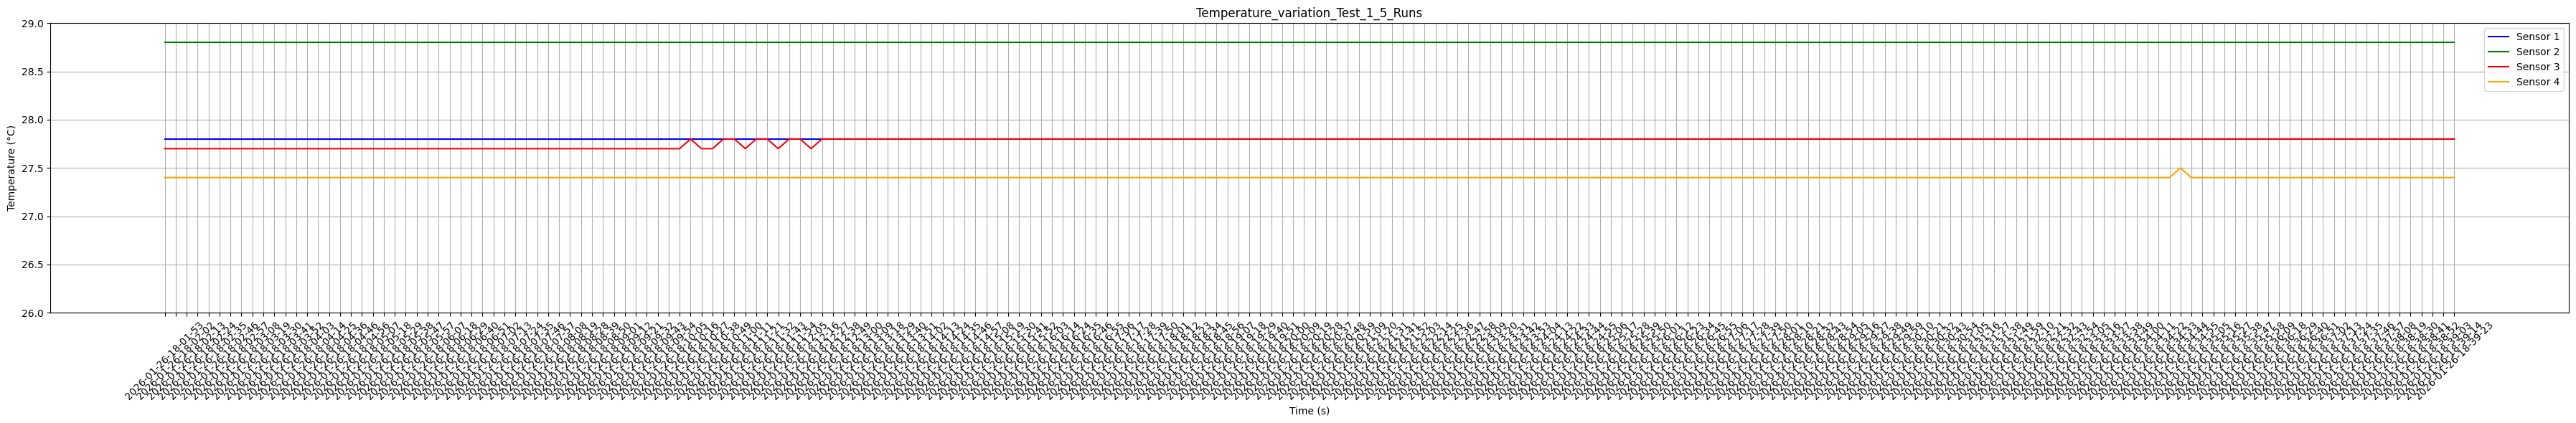

In [91]:
# time stamp is in column 0
# temperature is in column 14,15,16,17
run_time = run_log_np[:, 0]
run_temp = run_log_np[:, 14:18]
title = "Temperature_variation_Test_1_5_Runs"
save_path = folder_path + "\\"+title+".png"

#second_run_time = second_run_log_np[:, 0]
#second_run_temp = second_run_log_np[:, 14:18]
import matplotlib.pyplot as plt
plt.figure(figsize=(36, 6))
# use same color for same sensor in both runs
colors = ['blue', 'green', 'red', 'orange']
for i in range(4):
    plt.plot(run_time, run_temp[:, i], color=colors[i], label=f'Sensor {i+1}')
    #plt.plot(second_run_time, second_run_temp[:, i], color=colors[i])
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')

plt.title(title)
# roteate x ticks by 45 degrees
plt.xticks(rotation=45)
# Y axis limit from 26 to 29
plt.ylim(26, 29)
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig(save_path, dpi=300)
plt.show()

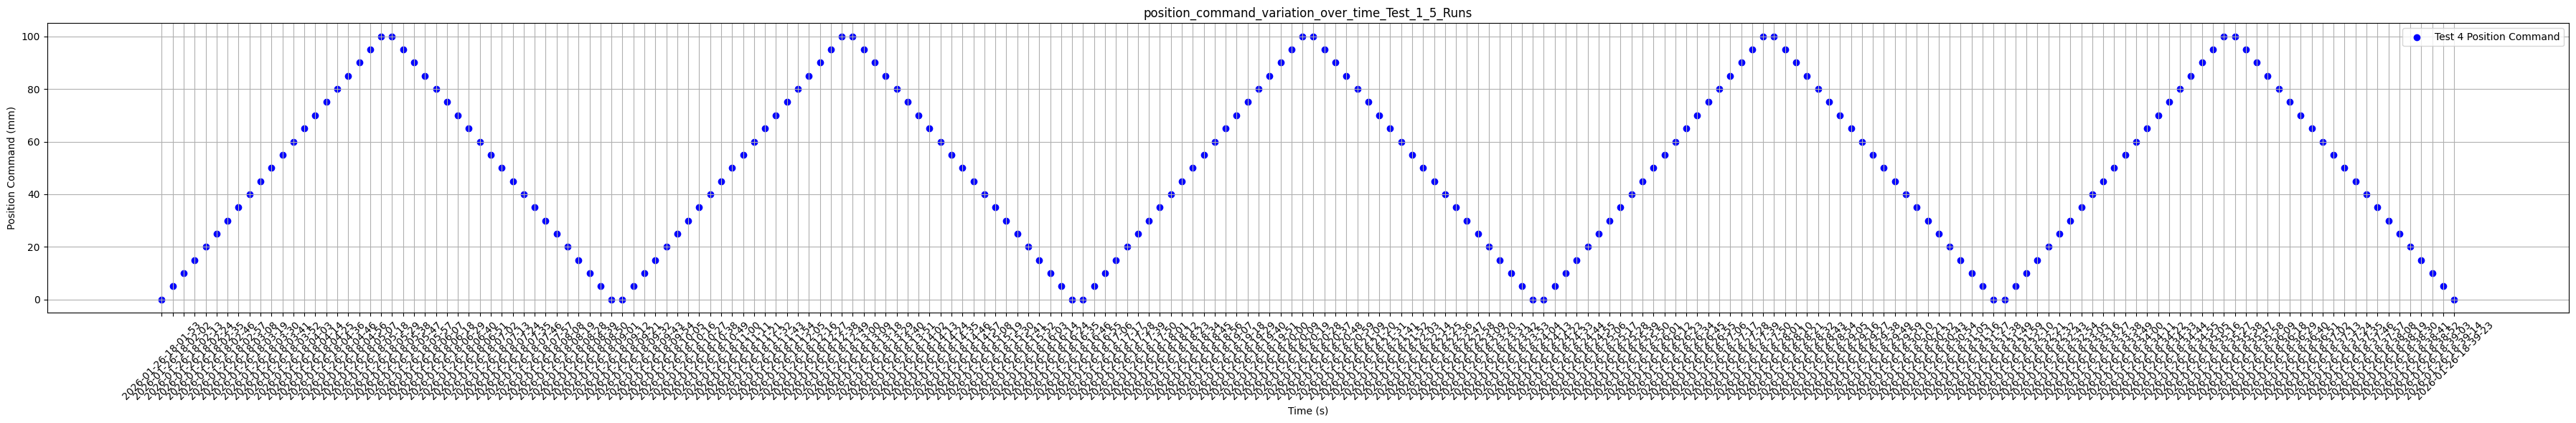

In [92]:
# plot position command vs time for both runs

run_time = run_log_np[:, 0]
title = "position_command_variation_over_time_Test_1_5_Runs"
save_path = folder_path + "\\"+title+".png"


# plot dimentions
plt.figure(figsize=(36, 6))
# lable indivitlal point value near the point in the plot 


plt.scatter(run_time, run_log_np[:, 6]-run_log_np[0,6], label='Test 4 Position Command', color='blue')

plt.xlabel('Time (s)')
plt.ylabel('Position Command (mm)')
plt.title(title)
# roteate x ticks by 45 degrees
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

### Plot the error values relative to Encoder position

In [94]:
run_log_np[0,6]
step_distance = (run_log_np[20,6]-run_log_np[0,6])/20  # mm

print("Initial Position (mm):", run_log_np[0,6])
print("Step distance (mm):", step_distance)

commanded_positions_first = [i * step_distance for i in range(0, 21,1)]
# print only six decimal places
commanded_positions_first = [round(pos, 6) for pos in commanded_positions_first]
print("Commanded Positions First Run (mm):", commanded_positions_first)

# add another 20 steps staring with last of commanded_positions_first then dicrese by step_distance
commanded_positions_second = [commanded_positions_first[-1] - i * step_distance for i in range(1, 21,1)]
commanded_positions_second = [round(pos, 6) for pos in commanded_positions_second]
print("Commanded Positions Second Run (mm):", commanded_positions_second)

commanded_positions = [0.0, 4.999833, 9.999666, 14.999499, 19.999332, 24.999166, 29.998999, 34.998832, 39.998665, 44.998498, 49.998331, 54.998164, 59.997997, 64.99783, 69.997663, 74.997497, 79.99733, 84.997163, 89.996996, 94.996829, 99.996662, 99.996662, 94.996829, 89.996996, 84.997163, 79.99733, 74.997496, 69.997663, 64.99783, 59.997997, 54.998164, 49.998331, 44.998498, 39.998665, 34.998832, 29.998999, 24.999165, 19.999332, 14.999499, 9.999666, 4.999833, 0.0]
print("Commanded Positions Combined (mm):", commanded_positions)
print("Length of Commanded Positions Combined:", len(commanded_positions))

Initial Position (mm): 125.942646
Step distance (mm): 4.999833100000001
Commanded Positions First Run (mm): [0.0, 4.999833, 9.999666, 14.999499, 19.999332, 24.999166, 29.998999, 34.998832, 39.998665, 44.998498, 49.998331, 54.998164, 59.997997, 64.99783, 69.997663, 74.997497, 79.99733, 84.997163, 89.996996, 94.996829, 99.996662]
Commanded Positions Second Run (mm): [94.996829, 89.996996, 84.997163, 79.99733, 74.997496, 69.997663, 64.99783, 59.997997, 54.998164, 49.998331, 44.998498, 39.998665, 34.998832, 29.998999, 24.999165, 19.999332, 14.999499, 9.999666, 4.999833, -0.0]
Commanded Positions Combined (mm): [0.0, 4.999833, 9.999666, 14.999499, 19.999332, 24.999166, 29.998999, 34.998832, 39.998665, 44.998498, 49.998331, 54.998164, 59.997997, 64.99783, 69.997663, 74.997497, 79.99733, 84.997163, 89.996996, 94.996829, 99.996662, 99.996662, 94.996829, 89.996996, 84.997163, 79.99733, 74.997496, 69.997663, 64.99783, 59.997997, 54.998164, 49.998331, 44.998498, 39.998665, 34.998832, 29.998999, 2

In [95]:
print(run_log_np[0, 6])
print(run_log_np[41, 6])

print(run_log_np[42, 6])
print(run_log_np[83, 6])

print(run_log_np[84, 6])
print(run_log_np[125, 6])

print(run_log_np[126, 6])
print(run_log_np[167, 6])

print(run_log_np[168, 6])
print(run_log_np[209, 6])

125.942646
125.942526
125.942538
125.942524
125.942567
125.942465
125.942515
125.942376
125.942388
125.942487


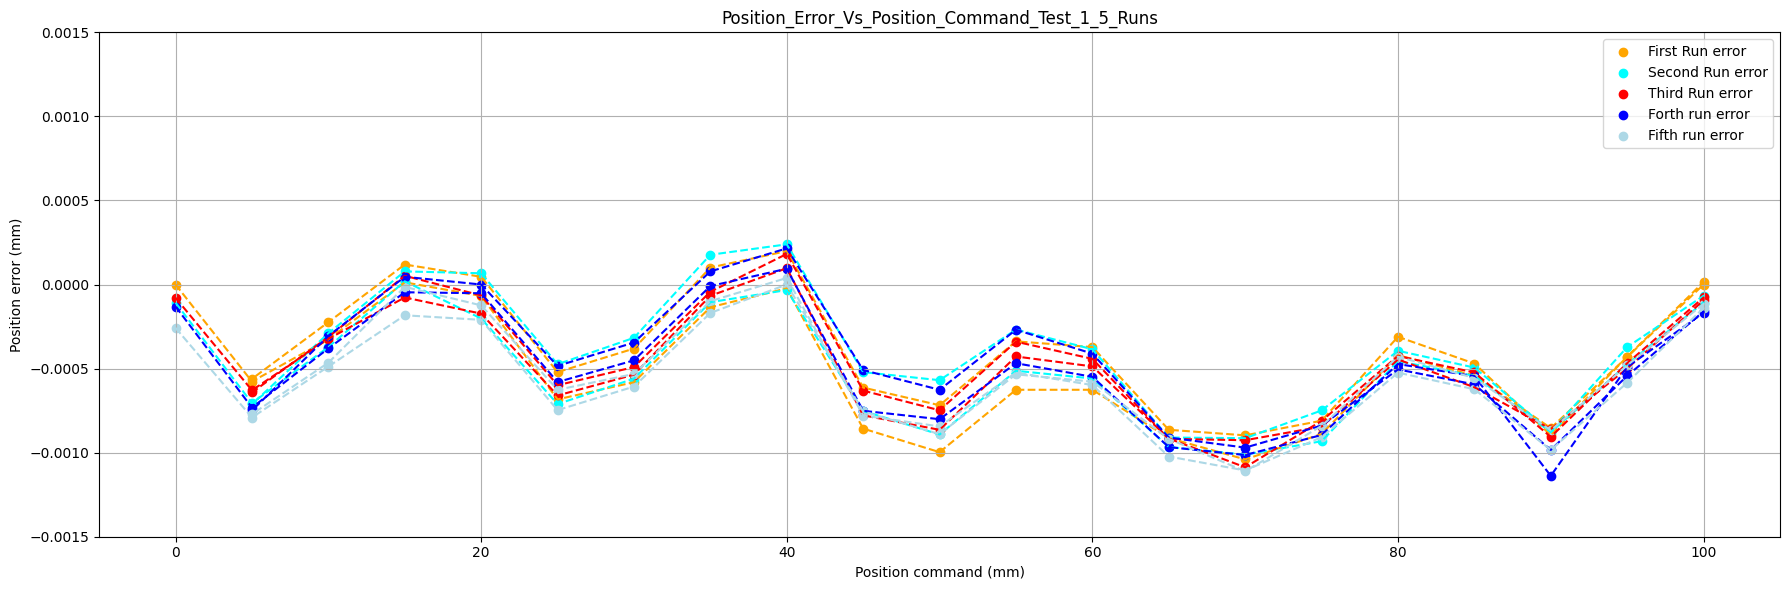

In [96]:
# plot position command vs time for both runs

run_log_np = run_log_np
title = "Position_Error_Vs_Position_Command_Test_1_5_Runs"
save_path = folder_path + "\\"+title+".png"

# plot dimentions
plt.figure(figsize=(18, 6))
# lable indivitlal point value near the point in the plot 

plt.scatter(commanded_positions[0:41], run_log_np[0:41, 6]-run_log_np[0,6] - commanded_positions[0:41], label='First Run error', color='orange')
plt.plot(commanded_positions[0:41], run_log_np[0:41, 6]-run_log_np[0,6] - commanded_positions[0:41], linestyle='--',  color='orange')
plt.scatter(commanded_positions[0:41], run_log_np[42:83, 6]-run_log_np[0,6] - commanded_positions[0:41], label='Second Run error', color='cyan')
plt.plot(commanded_positions[0:41], run_log_np[42:83, 6]-run_log_np[0,6] - commanded_positions[0:41], linestyle='--', color='cyan')
plt.scatter(commanded_positions[0:41], run_log_np[84:125, 6]-run_log_np[0,6] - commanded_positions[0:41], label='Third Run error', color='red')
plt.plot(commanded_positions[0:41], run_log_np[84:125, 6]-run_log_np[0,6] - commanded_positions[0:41], linestyle='--', color='red')
plt.scatter(commanded_positions[0:41], run_log_np[126:167, 6]-run_log_np[0,6] - commanded_positions[0:41], label='Forth run error', color='blue')
plt.plot(commanded_positions[0:41], run_log_np[126:167, 6]-run_log_np[0,6] - commanded_positions[0:41], linestyle='--', color='blue')
plt.scatter(commanded_positions[0:41], run_log_np[168:209, 6]-run_log_np[0,6] - commanded_positions[0:41], label='Fifth run error', color='lightblue')
plt.plot(commanded_positions[0:41], run_log_np[168:209, 6]-run_log_np[0,6] - commanded_positions[0:41], linestyle='--', color='lightblue')

plt.xlabel('Position command (mm)')
plt.ylabel('Position error (mm)')
plt.title(title)

plt.legend()
plt.ylim(-0.0015, 0.0015)
plt.grid()
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

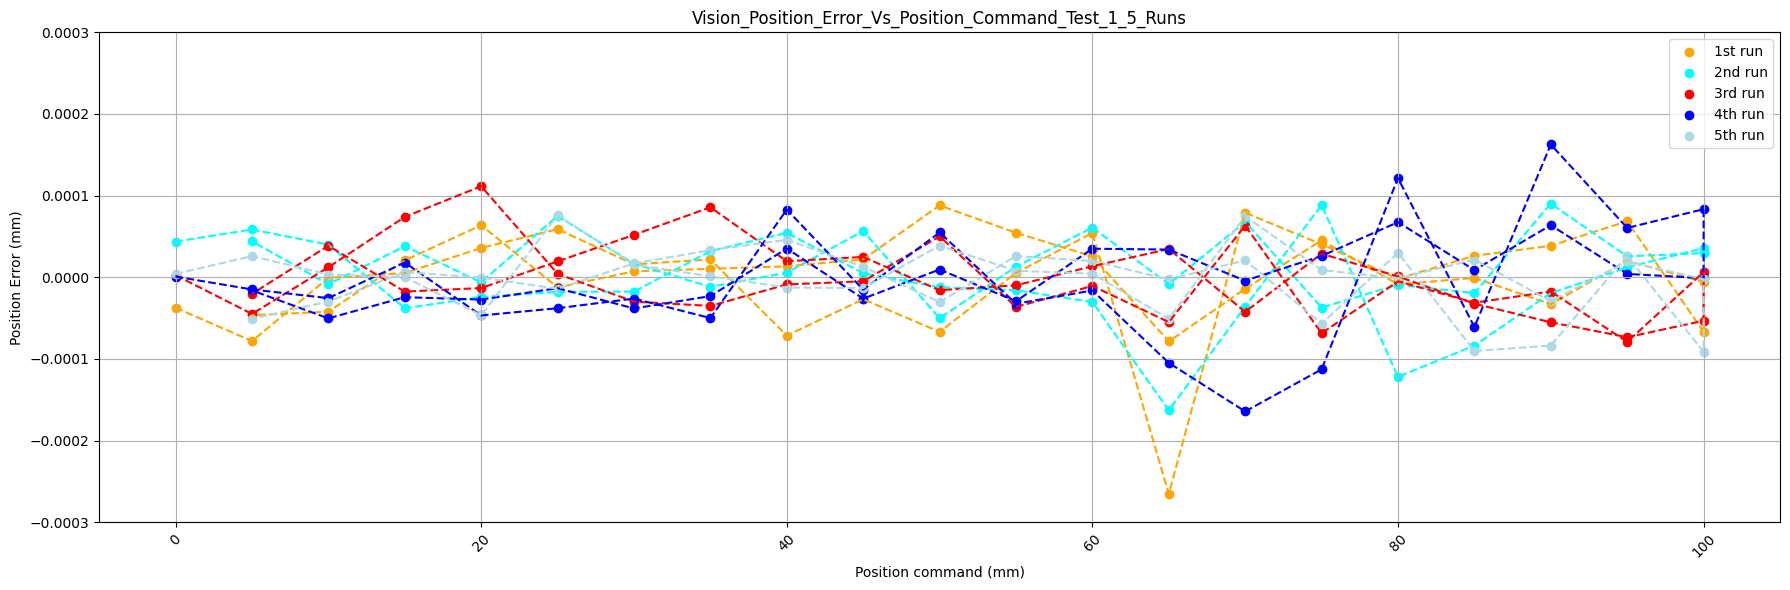

In [97]:
run_log_np = run_log_np
title = "Vision_Position_Error_Vs_Position_Command_Test_1_5_Runs"
save_path = folder_path + "\\"+title+".png"


# plot dimentions
plt.figure(figsize=(18, 6))
# lable indivitlal point value near the point in the plot 

plt.scatter(commanded_positions[0:41], (run_log_np[0:41, 11]-1500)*0.0008624306600050569, label='1st run', color='orange')
plt.plot(commanded_positions[0:41],    (run_log_np[0:41, 11]-1500)*0.0008624306600050569, linestyle='--', color='orange')
plt.scatter(commanded_positions[0:41], (run_log_np[42:83, 11]-1500)*0.0008624306600050569, label='2nd run', color='cyan')
plt.plot(commanded_positions[0:41],    (run_log_np[42:83, 11]-1500)*0.0008624306600050569, linestyle='--', color='cyan')
plt.scatter(commanded_positions[0:41], (run_log_np[84:125, 11]-1500)*0.0008624306600050569, label='3rd run', color='red')
plt.plot(commanded_positions[0:41],    (run_log_np[84:125, 11]-1500)*0.0008624306600050569, linestyle='--', color='red')
plt.scatter(commanded_positions[0:41], (run_log_np[126:167, 11]-1500)*0.0008624306600050569, label='4th run', color='blue')
plt.plot(commanded_positions[0:41],    (run_log_np[126:167, 11]-1500)*0.0008624306600050569, linestyle='--', color='blue')
plt.scatter(commanded_positions[0:41], (run_log_np[168:209, 11]-1500)*0.0008624306600050569, label='5th run', color='lightblue')
plt.plot(commanded_positions[0:41],    (run_log_np[168:209, 11]-1500)*0.0008624306600050569, linestyle='--', color='lightblue')

plt.xlabel('Position command (mm)')
plt.ylabel('Position Error (mm)')
plt.title(title)
# roteate x ticks by 45 degrees
plt.xticks(rotation=45)
plt.legend()
plt.ylim(-0.0003, 0.0003)
plt.grid()
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()